In [4]:
%matplotlib inline  
import librosa
import librosa.display
import IPython
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import ffmpeg

In [5]:
audio_data = r'C:\Users\admin\PycharmProjects\PythonLab5_P4D\audio.mp3'
y, sr = librosa.load(audio_data)

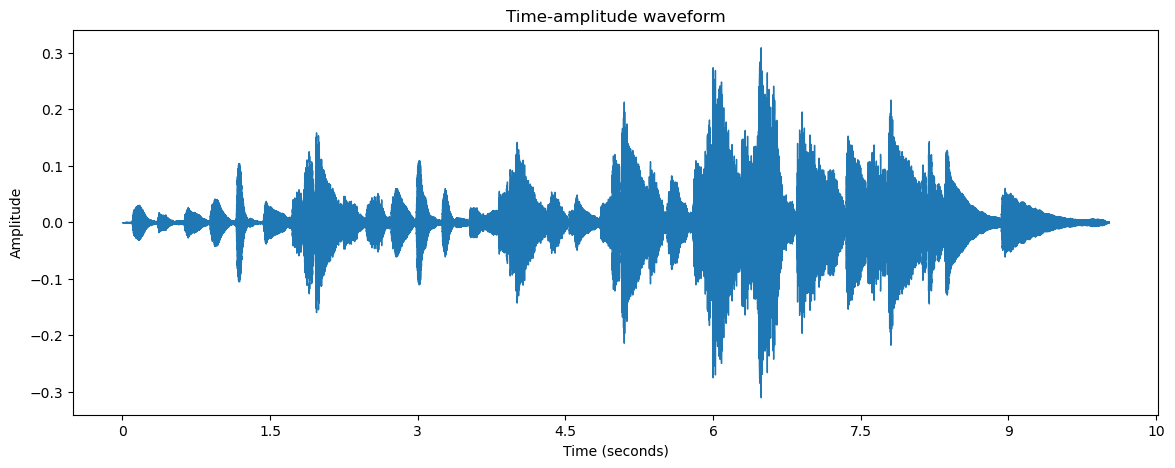

In [6]:
# 1. Амплитудно-временная форма сигнала
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title("Time-amplitude waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

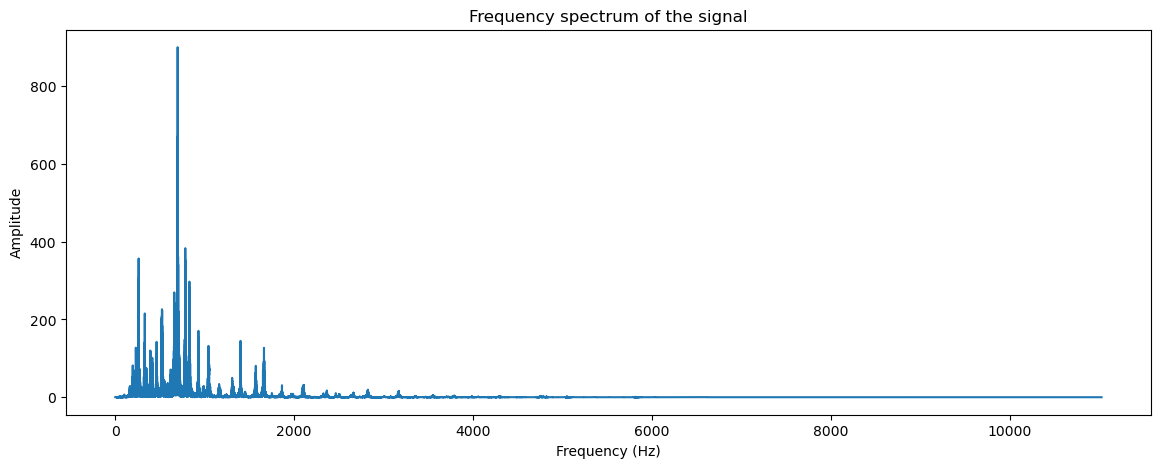

In [7]:
# 2. Частотный спектр (Прямое преобразование Фурье)
Y = np.fft.fft(y)
frequencies = np.fft.fftfreq(len(Y), 1/sr)
plt.figure(figsize=(14, 5))
plt.plot(frequencies[:len(frequencies)//2], np.abs(Y[:len(Y)//2]))
plt.title("Frequency spectrum of the signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

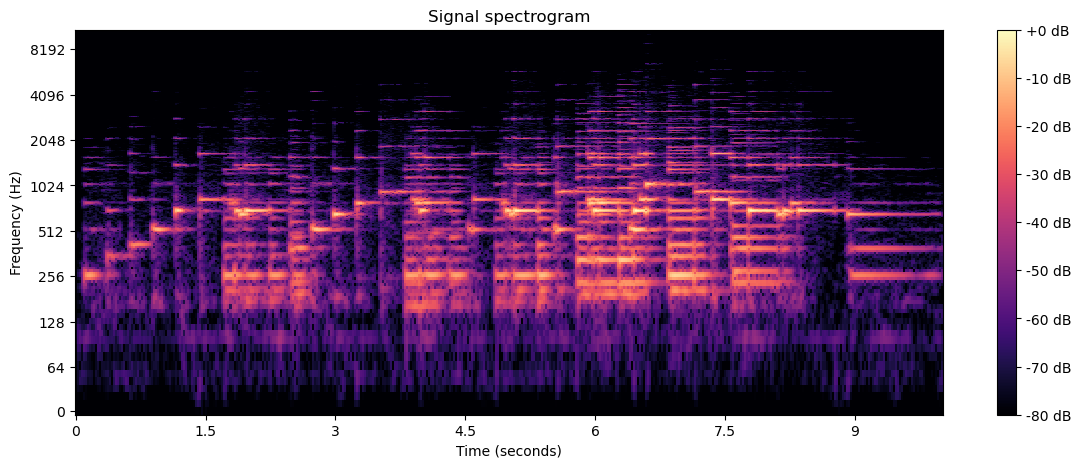

In [8]:
# 3. Спектрограмма сигнала (STFT)
plt.figure(figsize=(14, 5))
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.0f dB")
plt.title("Signal spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()

In [12]:
# Разделение гармонических и ударных сигналов
y_harmonic, y_percussive = librosa.effects.hpss(y)

значение темпа и количество бит
значение темпа и количество бит ошибка заключалась в том, что мы пытались передать больше позиционных аргументов, чем она может воспринять (takes from 0 to 1 positional arguments but 2 positional arguments were given) из-за чего не получалось установить data (вместо количества бит выводился массив, состоящий из номеров битов)

Обнаруженный темп: [117.45383523] ударов/мин
Количество битов: 12


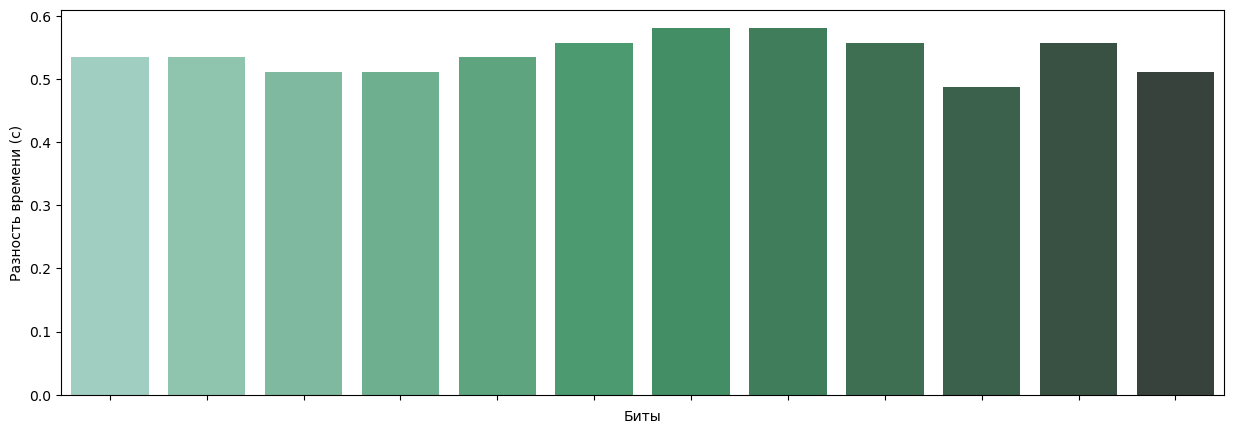

In [11]:
# Извлечение ритма
# Используем метод Harmonic-Percussive Source Separation (HPSS) для разделения звуковых сигналов на гармоническую и перкуссионную составляющие
y_harmonic, y_percussive = librosa.effects.hpss(y)

# Определяем темп и кадры ударов (битов) на основе перкуссионной составляющей
tempo, beat_frames = librosa.beat.beat_track(y=y_percussive, sr=sr)
print('Обнаруженный темп: ' + str(tempo) + ' ударов/мин')

# Преобразуем кадры битов в временные метки
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

# Вычисляем разности времени между последовательными битами
beat_time_diff = np.ediff1d(beat_times)

# Создаем массив номеров битов
beat_nums = np.arange(1, np.size(beat_times))

print(f'Количество битов: {len(beat_nums)}')

# Визуализация разностей времени между битами
fig, ax = plt.subplots()
fig.set_size_inches(15, 5)
ax.set_ylabel("Разность времени (с)")
ax.set_xlabel("Биты")

# Строим столбчатую диаграмму для разностей времени между битами
g = sns.barplot({"beats": beat_nums, "times": beat_time_diff}, x="beats", y="times", palette="BuGn_d", ax=ax)
g = g.set(xticklabels=[])

MFCC как numpy массив: [[-624.3932     -612.719      -608.1846     ... -568.5358
  -573.91565    -579.5302    ]
 [   1.4779041    17.517782     23.43644    ...   69.57381
    63.591995     57.088715  ]
 [   1.459143     16.156982     20.814428   ...   42.572235
    40.454727     37.552944  ]
 ...
 [   0.9047209     1.2420769    -0.6270802  ...    1.0109994
     0.93342644   -1.7496467 ]
 [   0.7948371     1.0313737    -1.3060114  ...   -3.6487381
    -3.3852546    -3.2132878 ]
 [   0.67895263    0.9613676    -1.4469295  ...   -9.535337
    -8.43589      -5.2424793 ]]


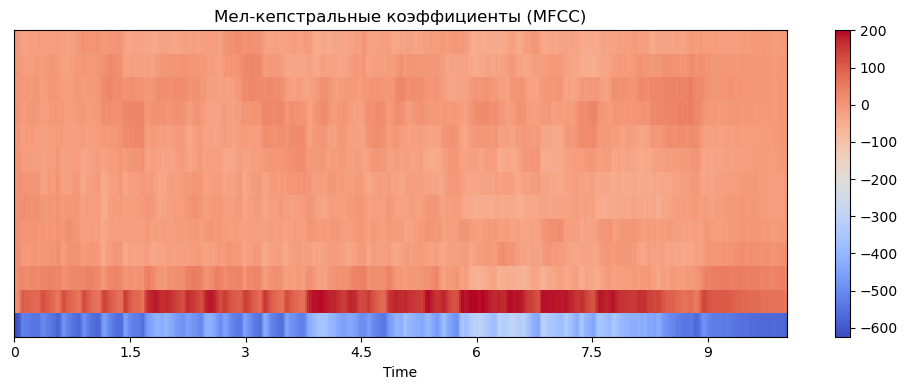

In [9]:
# 5. Вычисление мел-кепстральных коэффициентов (MFCC)
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print("MFCC как numpy массив:", mfccs)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.colorbar()
plt.title("Мел-кепстральные коэффициенты (MFCC)")
plt.tight_layout()
plt.show()

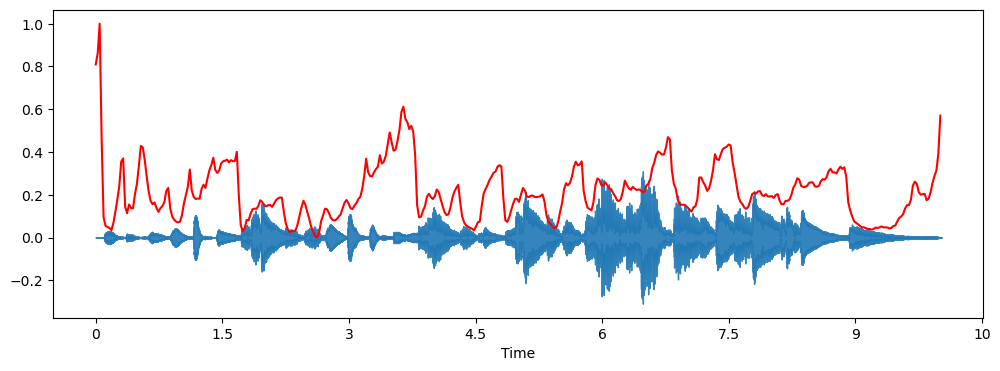

In [13]:
import sklearn

cent = librosa.feature.spectral_centroid(y=y, sr=sr)
spectral_centroids = cent[0]
spectral_centroids.shape

# Вычисление временной переменной для визуализации
plt.figure(figsize=(12, 4))
frames = range(len(spectral_centroids))
t = librosa.frames_to_time(frames)
# Нормализация спектрального центроида для визуализации
def normalize(y, axis=0):
    return sklearn.preprocessing.minmax_scale(y, axis=axis)
# Построение спектрального центроида вместе с формой волны
librosa.display.waveshow(y, sr=sr, alpha=0.9)
plt.plot(t, normalize(spectral_centroids), color='r')

Гармоническая и перкуссионная части сигнала — это два компонента, которые помогают описать и анализировать звуковые сигналы.

Гармоническая часть сигнала включает в себя синусоидальные колебания, которые возникают в результате одновременного звучания нескольких частот, связанных определенными соотношениями (обычно кратными). Она создаёт «тело» звука и отвечает за его тональность и тембр. Гармонические звуки часто ассоциируются с музыкальными инструментами, где основная нота (фундаментальная частота) и ее обертоны создают богатую текстуру звука.

Перкуссионная часть сигнала, наоборот, связана с ударами, щелчками и другими резкими звуковыми эффектами, которые не имеют четкой гармонической структуры. Она важна для ритма и динамики. Перкуссионные звуки часто возникают при ударных инструментах, таких как барабаны, и служат для создания акцентов и движения в музыке.

Text(0.5, 1.0, 'Harmonic + Percussive')

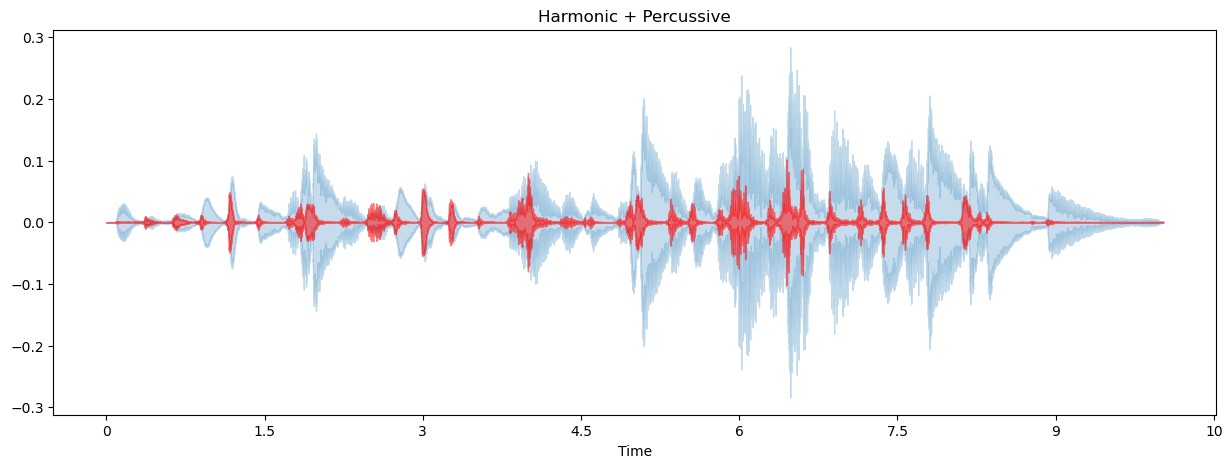

In [34]:
# Seperation of Harmonic and Percussive Signals
y_harmonic, y_percussive = librosa.effects.hpss(y)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(y_harmonic, sr=sr, alpha=0.25)
librosa.display.waveshow(y_percussive, sr=sr, color='r', alpha=0.5)
plt.title('Harmonic + Percussive')